In [10]:
%load_ext autoreload
%autoreload 2
# All auxiliary code is in ../src
import sys

sys.path.append("../src/")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
import numpy as np


In [13]:
from classification_utility import *

In [14]:
from classification_utility import split_in_train_and_validation


def get_f1_manual_model_validation(train_set, train_labels, model):
    train_set_splitted, validation_set, train_labels_splitted, validation_label = split_in_train_and_validation(train_set, train_labels)
    model.fit(train_set_splitted, train_labels_splitted)
    valid_pred = model.predict(validation_set)
    return metrics.f1_score(validation_label, valid_pred, average='macro')

def report_on_manual_model_validation(train_set, train_labels, model):
    train_set_splitted, validation_set, train_labels_splitted, validation_label = split_in_train_and_validation(train_set, train_labels)
    model.fit(train_set_splitted, train_labels_splitted)
    valid_pred = model.predict(validation_set)
    print(classification_report(validation_label, valid_pred, target_names=['out_top_20', 'top20']))

def compute_random_grid_search(estimator, param_grid):
    grid_search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_grid,
        cv=3,
        refit='f1_macro',
        scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
        verbose=True,
        n_jobs=5
    )
    grid_search.fit(train_set_us, train_labels_us)
    cv_results = grid_search.cv_results_

    results_df = pd.DataFrame({
        'params': cv_results['params'],
        'mean_accuracy': cv_results['mean_test_accuracy'],
        'mean_f1': cv_results['mean_test_f1_macro'],
        'mean_precision_macro': cv_results['mean_test_precision_macro'],
        'mean_recall_macro': cv_results['mean_test_recall_macro'],
    })
    return results_df, grid_search.best_params_, grid_search.best_score_, grid_search

def compute_grid_search(estimator, param_grid):
    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        cv=3,
        refit='f1_macro',
        scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
        verbose=True,
        n_jobs=5
    )
    grid_search.fit(train_set_us, train_labels_us)
    cv_results = grid_search.cv_results_
    results_df = pd.DataFrame({
        'params': cv_results['params'],
        'mean_accuracy': cv_results['mean_test_accuracy'],
        'mean_f1_macro': cv_results['mean_test_f1_macro'],
        'mean_precision_macro': cv_results['mean_test_precision_macro'],
        'mean_recall_macro': cv_results['mean_test_recall_macro'],
    })
    return results_df, grid_search.best_params_, grid_search.best_score_, grid_search

import json

def save_classification_res(method_name, params, test_pred_labels, probability_class_res):
    fpr, tpr, roc_auc, precision, recall, auc_pr = probability_class_res

    # Prepara i dati da salvare
    results = {
        "method_name": method_name,
        "params": params,
        "predicted_labels": list(map(bool, test_pred_labels)),
        "roc_curve": {
            "fpr": fpr.tolist(),  # Falsi positivi
            "tpr": tpr.tolist(),  # Veri positivi
            "roc_auc": float(roc_auc)   # Area sotto la curva ROC
        },
        "pr_curve": {
            "precision": precision.tolist(),  # Precisione
            "recall": recall.tolist(),        # Richiamo
            "auc_pr": float(auc_pr)                # Area sotto la curva Precision-Recall
        }
    }
    print(results)
    # Nome del file JSON
    filename = f"classification_results/{method_name}_res.json"

    # Salva i risultati in formato JSON
    with open(filename, 'w') as f:
        json.dump(results, f, indent=4)  # indent=4 per renderlo leggibile

    print(f"Risultati salvati in '{filename}'")

import json
import os

def load_classification_res(method_name):

    filename = f"classification_results/{method_name}_res.json"

    if not os.path.exists(filename):
        raise FileNotFoundError(f"Il file '{filename}' non esiste.")

    with open(filename, 'r') as f:
        results = json.load(f)

    method_name = results["method_name"]
    params = results["params"]
    predicted_labels = list(map(bool, results["predicted_labels"]))
    roc_curve = results["roc_curve"]
    pr_curve = results["pr_curve"]

    fpr = roc_curve["fpr"]
    tpr = roc_curve["tpr"]
    roc_auc = roc_curve["roc_auc"]
    precision = pr_curve["precision"]
    recall = pr_curve["recall"]
    auc_pr = pr_curve["auc_pr"]

    probability_class_res = (fpr, tpr, roc_auc, precision, recall, auc_pr)

    return method_name, params, predicted_labels, probability_class_res


## SVM

In [17]:
train_set, test_set, train_labels, test_labels = train_test_for_distance()

### Model selection

#### Undersampling strategy

In [5]:
train_set_us, train_labels_us = perform_best_under_sampling(train_set, train_labels)

In [14]:
get_label_percentages(train_labels_us, ['out_top_20', 'top_20'])

,Label,Percentage
0,out_top_20,59.880045
1,top_20,40.119955


Come primo tentativo proveremo a testare differenti iper parametri per l'algoritmo. In questo senso dividiamo manualmente il training set in training set e validation in modo da poter effettuare model selection senza intaccare i dati di test

Cominciamo le nostre prove con un separatore lineare con un valore di C pari a uno e valutiamo le performance f1_macro del metodo sui dati di validazione

In [7]:
from sklearn.svm import LinearSVC
linear_C1 = LinearSVC(C=1, random_state=42)
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, linear_C1)}")
report_on_manual_model_validation(train_set_us, train_labels_us, linear_C1)

F1 macro: 0.7003545143774308
              precision    recall  f1-score   support

  out_top_20       0.74      0.81      0.77     33156
       top20       0.67      0.59      0.63     22215

    accuracy                           0.72     55371
   macro avg       0.71      0.70      0.70     55371
weighted avg       0.72      0.72      0.72     55371



Proviamo facendo variare il valore di C a vedere se cambiano le performance sulla metrica f1

In [8]:
linear_C10 = LinearSVC(C=10, random_state=42)
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, linear_C10)}")
report_on_manual_model_validation(train_set_us, train_labels_us, linear_C10)

F1 macro: 0.7003545143774308
              precision    recall  f1-score   support

  out_top_20       0.74      0.81      0.77     33156
       top20       0.67      0.59      0.63     22215

    accuracy                           0.72     55371
   macro avg       0.71      0.70      0.70     55371
weighted avg       0.72      0.72      0.72     55371



Computazionalmente gestibile una model selection con Grid search quindi procedo!

Ok proviamo grid search passando tutti i dati a disposizione per Linear search

In [17]:
param_grid = {'C': [0.001, 0.01, 1, 10, 100, 1000]}
results, best_params_f1_macro, best_score_f1_macro, _ = compute_grid_search(LinearSVC(random_state=42), param_grid)

print(results)
print("Best Parameters:", best_params_f1_macro)
print("Best Cross-Validation F1 Score:", best_score_f1_macro)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
         params  mean_accuracy  mean_f1_macro  mean_precision_macro  \
0  {'C': 0.001}       0.676262       0.642856              0.658176   
1   {'C': 0.01}       0.676132       0.642748              0.658001   
2      {'C': 1}       0.676148       0.642776              0.658019   
3     {'C': 10}       0.676148       0.642776              0.658019   
4    {'C': 100}       0.676148       0.642776              0.658019   
5   {'C': 1000}       0.676148       0.642776              0.658019   

   mean_recall_macro  
0           0.644259  
1           0.644186  
2           0.644215  
3           0.644215  
4           0.644215  
5           0.644215  
Best Parameters: {'C': 0.001}
Best Cross-Validation F1 Score: 0.6428561371430324


Proviamo un kernel più complicato (rbf) con dati di default e valutiamo i suoi score su validation set. Due sono gli iperparametri da "tunare"
+ C: è un parametro di regolarizzazione
    + a lower C will encourage a larger margin, therefore a simpler decision function, at the cost of training accuracy
+ gamma: controlla quanto è ampia l'influenza di un singolo campione di training nel definire i confini di decisione. In altre parole, gamma regola l'importanza della distanza tra i punti.
    + gamma piccolo (0.1) -> Un singolo punto ha un effetto a lungo raggio -> i confini di decisione sono più lisci e semplici -> può portare a underfitting
    + gamma grande (100) -> Un singolo punto ha un effetto solo a breve distanza -> i confini di decisione diventano molto complessi e frastagliati, adattandosi strettamente ai dati di training -> può portare a overfitting

Immagine che fa vedere come si calcolano gamma scale e auto

In [13]:
def get_gamma_scale(train_set):
    var = np.var(train_set, axis=0).mean()
    return 1 / (train_set.shape[1] * var)

def get_gamma_auto(train_set):
    return 1 / (train_set.shape[1])

In [16]:
print(get_gamma_scale(train_set_splitted))
print(get_gamma_auto(train_set_splitted))

0.09031660655410391
0.05555555555555555


In [51]:
from sklearn.svm import SVC

first_svm = SVC(kernel='rbf', C=1, gamma='scale')
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, first_svm)}")

F1 macro: 0.7340111468301151


Proviamo con altre combinazioni di C e gamma

In [10]:
from sklearn.svm import SVC

second_svm = SVC(kernel='rbf', C=1, gamma='auto')
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, second_svm)}")

F1 macro: 0.7295565989691184


In [28]:
from sklearn.svm import SVC

third_svm = SVC(kernel='rbf', C=0.5, gamma=0.5)
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, third_svm)}")

F1 macro: 0.7510544043920777


Computazionalmente impossibile usare una random o grid search con cross validation

In [ ]:


param_grid = {'C': [0.5, 1, 10],
              'gamma': ['scale', 'auto', 0.5, 1, 10]}

#results, best_params_f1_macro, best_score_f1_macro, _ = compute_random_grid_search(SVC(kernel='rbf', random_state=42), param_grid)

#print(results)
#print("Best Parameters:", best_params_f1_macro)
#print("Best Cross-Validation F1 Score:", best_score_f1_macro)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


#### Allenamento modelli con tutti i dati di training

Abbiamo selezionato gli **iperparametri migliori** per i classificatori:
- **Linear SVM** utilizzando **Grid Search**.
- **RBF SVM** tramite una **verifica manuale**.

Alleniamo dunque i modelli sfruttando **tutti i dati di training** a disposizione. Tuttavia, siccome **LinearSVM** e **SVM** non supportano nativamente la previsione delle probabilità tramite il metodo **`predict_proba`**, non possiamo usare in maniera diretta tali modelli per ottenere probabilità utili a:

- **Calcolare metriche** come la **ROC/AUC**.
- **Definire soglie di decisione personalizzate**.

Per ovviare a questa limitazione, è possibile utilizzare **`CalibratedClassifierCV`**, uno strumento che consente di "wrappare" un classificatore esistente e **calibrare le probabilità** utilizzando tecniche specifiche, come:

- **Platt Scaling**: sfrutta il parametro **`decision_function`**, che rappresenta la **distanza di ciascun punto dall'iperpiano separatore**.
Applica una **regressione logistica** ai punteggi grezzi per calcolare la probabilità che ciascun punto appartenga alla **classe positiva**.

La probabilità è ottenuta tramite una funzione che fornisce una probabilità calibrata, compresa tra 0 e 1, interpretabile come il grado di appartenenza alla **classe positiva**.

In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.svm import LinearSVC

linear_svm_best_params_from_gs = {'C': 0.001, 'random_state':42}
linear_svm_chosen = build_model_with_params(LinearSVC(), linear_svm_best_params_from_gs)
linear_svm_chosen = CalibratedClassifierCV(linear_svm_chosen)
linear_svm_chosen.fit(train_set_us, train_labels_us)

CalibratedClassifierCV(estimator=LinearSVC(C=0.001, random_state=42))

In [19]:
from sklearn.svm import SVC

rbf_svm_params = {'kernel': 'rbf', 'C': 0.5, 'gamma': 0.5, 'random_state': 42}

rbf_svm_chosen = build_model_with_params(SVC(), rbf_svm_params)
rbf_svm_chosen = CalibratedClassifierCV(rbf_svm_chosen, cv=2, n_jobs=5)
rbf_svm_chosen.fit(train_set_us, train_labels_us)

CalibratedClassifierCV(cv=2, estimator=SVC(C=0.5, gamma=0.5, random_state=42),
                       n_jobs=5)

### Model evaluation

Creiamo grafici per i migliori modelli individuati sia Linear che rbf

In [20]:
test_pred_linear_svm = linear_svm_chosen.predict(test_set)

In [21]:
print(classification_report(test_labels, test_pred_linear_svm, target_names=['not top20', 'top20']))

              precision    recall  f1-score   support

   not top20       0.88      0.92      0.90     28066
       top20       0.33      0.24      0.28      4520

    accuracy                           0.83     32586
   macro avg       0.61      0.58      0.59     32586
weighted avg       0.81      0.83      0.82     32586



In [22]:
test_pred_rbf_svm = rbf_svm_chosen.predict(test_set)

In [23]:
print(classification_report(test_labels, test_pred_rbf_svm, target_names=['not top20', 'top20']))

              precision    recall  f1-score   support

   not top20       0.90      0.93      0.91     28066
       top20       0.42      0.33      0.37      4520

    accuracy                           0.84     32586
   macro avg       0.66      0.63      0.64     32586
weighted avg       0.83      0.84      0.84     32586



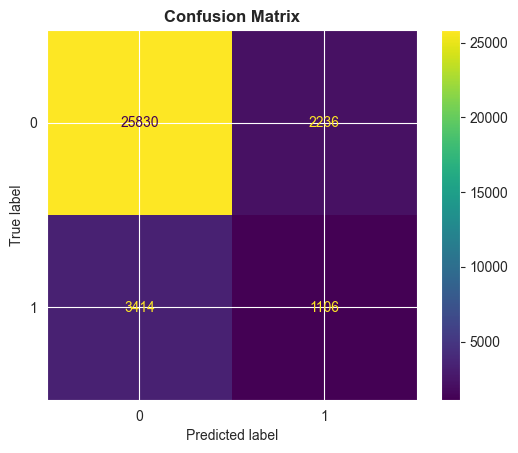

In [24]:
plot_confusion_matrix(linear_svm_chosen, test_labels, test_pred_linear_svm)

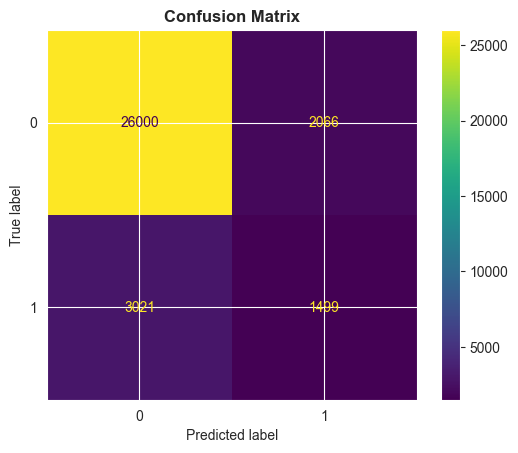

In [25]:
plot_confusion_matrix(rbf_svm_chosen, test_labels, test_pred_rbf_svm)

AUC-PR of the classifier: 0.2705
AUC-ROC of the classifier: 0.6929


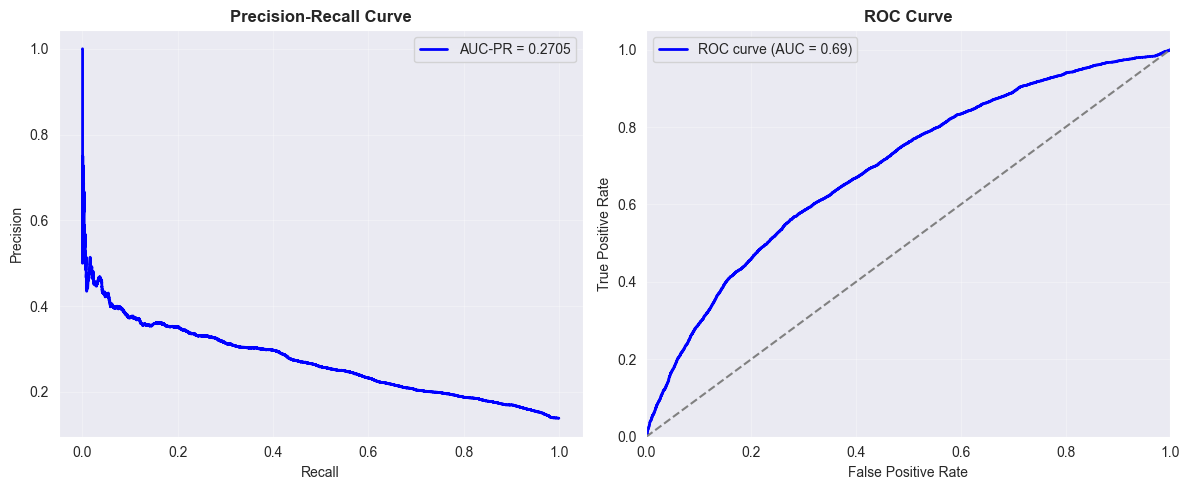

In [26]:
results_linear_svm = plot_PR_ROC_AUC(linear_svm_chosen, test_set, test_labels)

AUC-PR of the classifier: 0.3537
AUC-ROC of the classifier: 0.7573


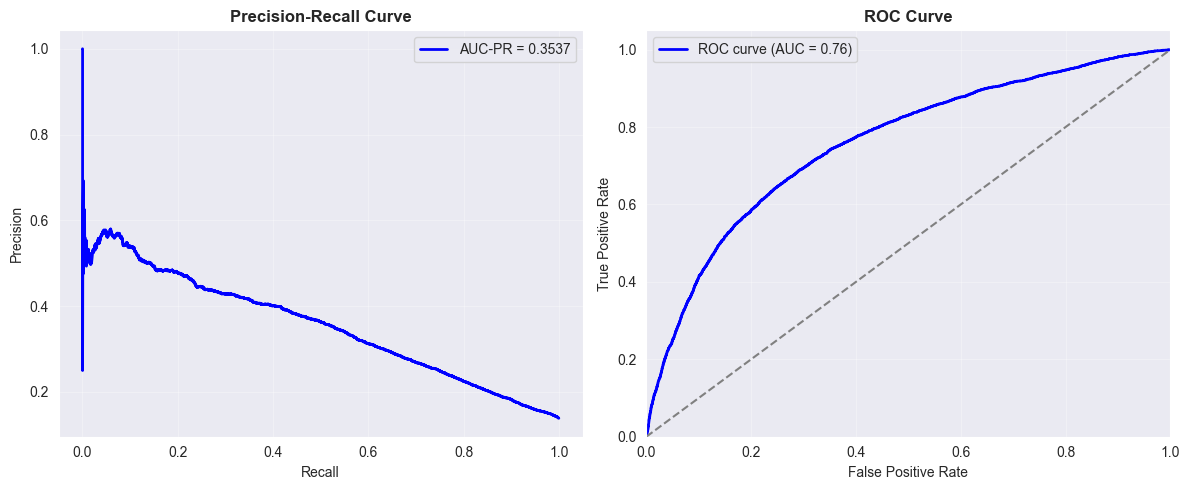

In [27]:
results_rbf_svm = plot_PR_ROC_AUC(rbf_svm_chosen, test_set, test_labels)

In [28]:
save_classification_res('linear_svm_under_sampling', linear_svm_best_params_from_gs, test_pred_linear_svm, results_linear_svm)

{'method_name': 'linear_svm_under_sampling', 'params': {'C': 0.001, 'random_state': 42}, 'predicted_labels': [True, False, True, True, False, False, True, False, True, True, True, False, False, True, False, True, False, False, True, True, False, False, False, False, False, False, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, True, False, True, True, True, False, False, True, False, Fal

In [29]:
rbf_svm_params = {'kernel': 'rbf', 'C': 0.5, 'gamma': 0.5, 'random_state': 42}

save_classification_res('rbf_svm_under_sampling', rbf_svm_params, test_pred_rbf_svm, results_rbf_svm)

{'method_name': 'rbf_svm_under_sampling', 'params': {'kernel': 'rbf', 'C': 0.5, 'gamma': 0.5, 'random_state': 42}, 'predicted_labels': [False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, 

## KNN

In [30]:
train_set, test_set, train_labels, test_labels = train_test_for_distance()

### Model selection

In [31]:
train_set_us, train_labels_us = perform_best_under_sampling(train_set, train_labels)

#### Undersampling strategy

In [32]:
knn = KNeighborsClassifier(n_neighbors=2, algorithm='ball_tree', metric='euclidean')
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, knn)}")

F1 macro: 0.6963732156936641


Facciamo variare il valore di n_neighbors e visualizziamo le performance

In [33]:
knn = KNeighborsClassifier(n_neighbors=4, algorithm='ball_tree', metric='euclidean')
print(f"F1 macro: {get_f1_manual_model_validation(train_set_us, train_labels_us, knn)}")

F1 macro: 0.7240865369046954


Come classificare istanza di test sulla base di k vicini? uniform vote o weighted on distance

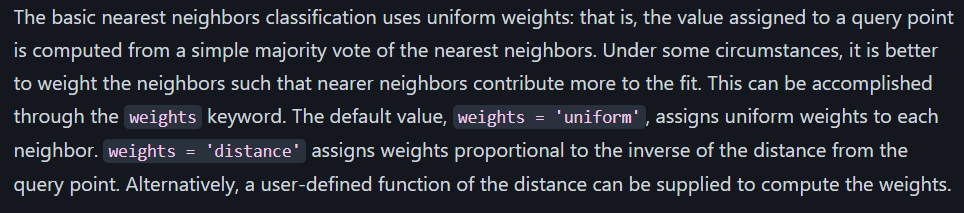

Tempi ragionevoli consentono di usare grid search per trovare parametri migliori

In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {'n_neighbors': [2, 4, 8, 16, 32, 64],
              'weights': ['uniform', 'distance']}

results, best_params_f1_macro, best_score_f1_macro, _ = compute_random_grid_search(
    KNeighborsClassifier(algorithm='ball_tree', metric='euclidean'), param_grid)

print(results)
print("Best Parameters:", best_params_f1_macro)
print("Best Cross-Validation F1 Score:", best_score_f1_macro)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
                                       params  mean_accuracy   mean_f1
0   {'weights': 'distance', 'n_neighbors': 2}       0.603455  0.554367
1   {'weights': 'uniform', 'n_neighbors': 32}       0.663232  0.613761
2  {'weights': 'distance', 'n_neighbors': 16}       0.651160  0.603999
3    {'weights': 'uniform', 'n_neighbors': 2}       0.632316  0.544443
4   {'weights': 'uniform', 'n_neighbors': 16}       0.658139  0.605771
5  {'weights': 'distance', 'n_neighbors': 32}       0.659461  0.612635
6   {'weights': 'uniform', 'n_neighbors': 64}       0.667599  0.618667
7   {'weights': 'distance', 'n_neighbors': 4}       0.624829  0.576439
8   {'weights': 'distance', 'n_neighbors': 8}       0.639528  0.591841
9    {'weights': 'uniform', 'n_neighbors': 4}       0.641619  0.572065
Best Parameters: {'weights': 'uniform', 'n_neighbors': 64}
Best Cross-Validation F1 Score: 0.6186670040355494


Sembra miglorare con valori di k elevati -> spostiamo parametri verso quei valori fino al parametro consigliato (rad(training_size))

In [7]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import math

param_grid = {'n_neighbors': [128, 256, int(math.sqrt(train_set_us.shape[0]))],
              'weights': ['uniform', 'distance']}

results, best_params_f1_macro, best_score_f1_macro, _ = compute_grid_search(
    KNeighborsClassifier(algorithm='ball_tree', metric='euclidean'), param_grid)

print(results)
print("Best Parameters:", best_params_f1_macro)
print("Best Cross-Validation F1 Score:", best_score_f1_macro)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
                                        params  mean_accuracy   mean_f1
0   {'n_neighbors': 128, 'weights': 'uniform'}       0.669430  0.620066
1  {'n_neighbors': 128, 'weights': 'distance'}       0.668585  0.620242
2   {'n_neighbors': 256, 'weights': 'uniform'}       0.670324  0.619188
3  {'n_neighbors': 256, 'weights': 'distance'}       0.670454  0.620275
4   {'n_neighbors': 429, 'weights': 'uniform'}       0.670492  0.618423
5  {'n_neighbors': 429, 'weights': 'distance'}       0.670681  0.618929
Best Parameters: {'n_neighbors': 256, 'weights': 'distance'}
Best Cross-Validation F1 Score: 0.6202749398134807


#### Oversampling strategy

In [34]:
from classification_utility import perform_smote_over_sampling

train_set_smote, train_labels_smote = perform_smote_over_sampling(train_set, train_labels)

In [35]:
import math

math.sqrt(train_set_smote.shape[0])

819.7902170677569

Troppo costosa una grid search! Proviamo semplicemente una configurazione

In [36]:


import math

params_knn_smote = {
    'n_neighbors': int(math.sqrt(train_set_smote.shape[0])),
    'algorithm': 'ball_tree',
    'metric': 'euclidean',
    'weights': 'distance'
}

knn_smote_model_chosen = build_model_with_params(KNeighborsClassifier(), params_knn_smote)
f1_knn_smote_res = get_f1_manual_model_validation(train_set_smote, train_labels_smote, knn_smote_model_chosen)
print(f"F1 macro: {f1_knn_smote_res}")

F1 macro: 0.7570405702745427


#### Allenamento modelli con tutti i dati di training

In [37]:
best_params_knn_unders_from_gs = {'n_neighbors': 256, 'weights': 'distance', 'algorithm':'ball_tree', 'metric':'euclidean'}
knn_under_s_model_chosen = build_model_with_params(KNeighborsClassifier(), best_params_knn_unders_from_gs)
knn_under_s_model_chosen.fit(train_set_us, train_labels_us)

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_neighbors=256,
                     weights='distance')

In [38]:
knn_smote_model_chosen.fit(train_set_smote, train_labels_smote)

KNeighborsClassifier(algorithm='ball_tree', metric='euclidean', n_neighbors=819,
                     weights='distance')

### Model evaluation

Nel test le nostre label sono sbilanciate quindi accuracy non è una ottima metrica

In [67]:
print(get_label_percentages(test_labels))

       Label  Percentage
0  not top20   86.129012
1     top_20   13.870988


In [39]:
test_pred_knn_under = knn_under_s_model_chosen.predict(test_set)

In [40]:
test_pred_knn_smote = knn_smote_model_chosen.predict(test_set)

In [41]:
print(classification_report(test_labels, test_pred_knn_under, target_names=['not top20', 'top20']))

              precision    recall  f1-score   support

   not top20       0.90      0.92      0.91     28066
       top20       0.39      0.34      0.36      4520

    accuracy                           0.84     32586
   macro avg       0.64      0.63      0.63     32586
weighted avg       0.83      0.84      0.83     32586



In [42]:
print(classification_report(test_labels, test_pred_knn_smote, target_names=['not top20', 'top20']))

              precision    recall  f1-score   support

   not top20       0.90      0.90      0.90     28066
       top20       0.38      0.37      0.37      4520

    accuracy                           0.83     32586
   macro avg       0.64      0.64      0.64     32586
weighted avg       0.83      0.83      0.83     32586



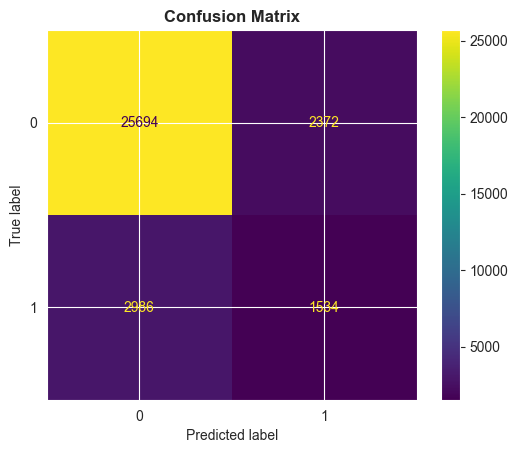

In [43]:
plot_confusion_matrix(knn_under_s_model_chosen, test_labels, test_pred_knn_under)

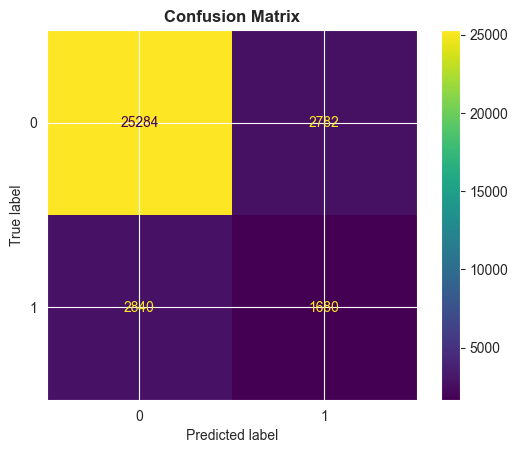

In [44]:
plot_confusion_matrix(knn_smote_model_chosen, test_labels, test_pred_knn_smote)

AUC-PR of the classifier: 0.3457
AUC-ROC of the classifier: 0.7460


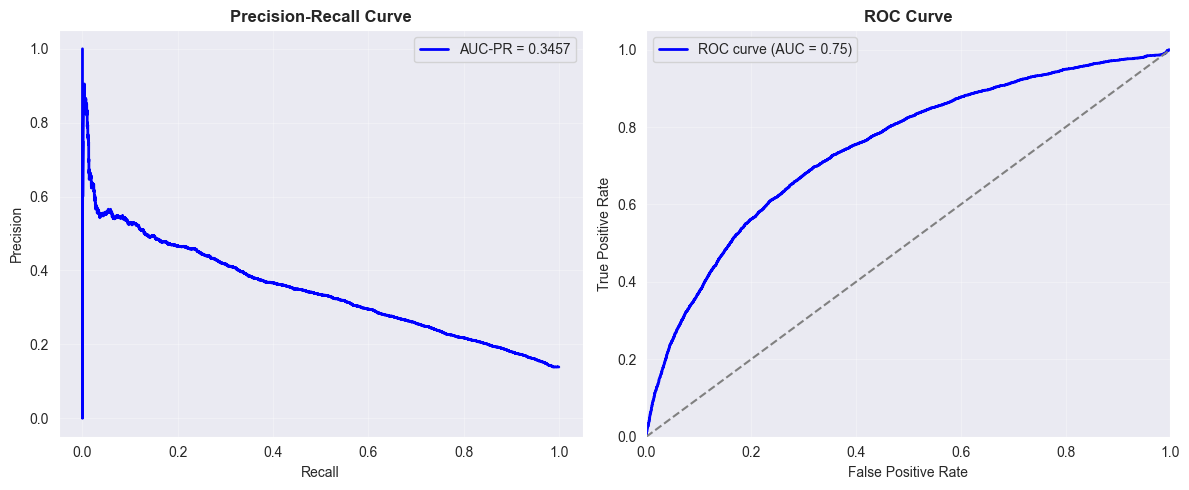

In [45]:
results_knn_under = plot_PR_ROC_AUC(knn_under_s_model_chosen, test_set, test_labels)

AUC-PR of the classifier: 0.3459
AUC-ROC of the classifier: 0.7461


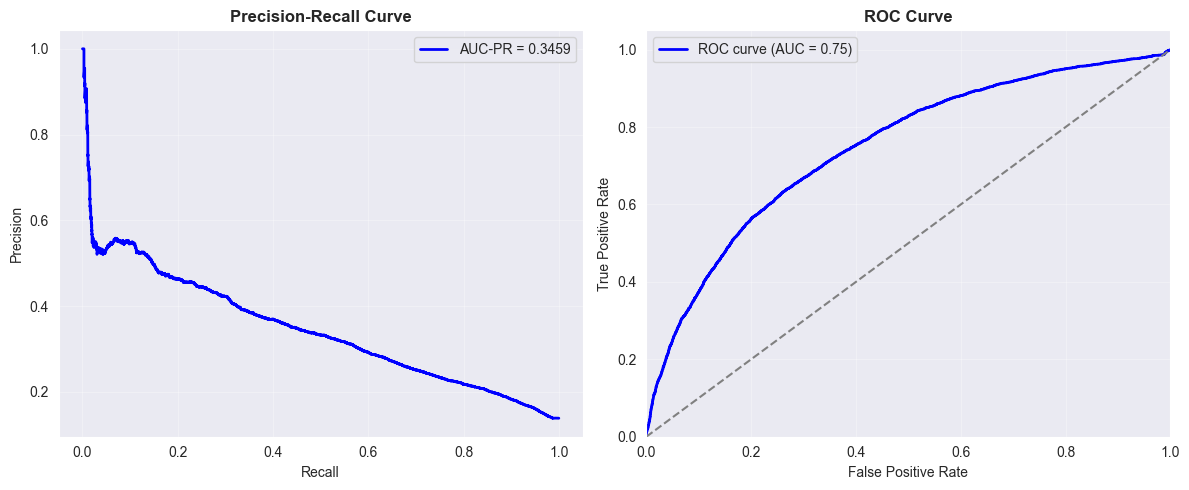

In [46]:
results_knn_smote = plot_PR_ROC_AUC(knn_smote_model_chosen, test_set, test_labels)

In [47]:
save_classification_res('knn_under_sampling', best_params_knn_unders_from_gs, test_pred_knn_under, results_knn_under)

{'method_name': 'knn_under_sampling', 'params': {'n_neighbors': 256, 'weights': 'distance', 'algorithm': 'ball_tree', 'metric': 'euclidean'}, 'predicted_labels': [True, False, True, True, False, False, True, True, False, True, False, False, False, True, False, True, False, False, True, True, True, False, False, False, False, False, False, True, True, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, 

In [48]:
save_classification_res('knn_smote_sampling', params_knn_smote, test_pred_knn_smote, results_knn_smote)

{'method_name': 'knn_smote_sampling', 'params': {'n_neighbors': 819, 'algorithm': 'ball_tree', 'metric': 'euclidean', 'weights': 'distance'}, 'predicted_labels': [True, False, True, True, False, False, True, True, True, True, False, False, False, True, False, True, False, False, True, True, True, False, False, False, False, False, True, True, True, True, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False

## Rule based classifier

Non è un metodo per distanza, uso altro dataset

In [49]:
train_set, test_set, train_labels, test_labels = train_test_for_non_distance()

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


### Model selection

#### Undersampling strategy

In [50]:
from src.classification_utility import perform_best_under_sampling

train_set_us, train_labels_us = perform_best_under_sampling(train_set, train_labels)

Cominciamo provando varie configurazioni possibili per iperparametri modello (alcune come max_rules, max_rule_conds non sono veri e propri iperparametri ma condizioni di early stopping)

Due iperarametri da "tunare":
+ k : Numero massimo di iterazioni per rifinire una regola generata. Iterazioni più alte migliorano il fitting, ma aumentano il rischio di overfitting.
+ prune_size : Percentuale del training set riservata per la potatura.	Maggiore pruning aumenta la generalizzazione; meno pruning favorisce l'adattamento ai dati.

In [29]:
from wittgenstein import RIPPER
ripper = RIPPER(prune_size=0.5, k=3, max_rules=25, max_rule_conds=14)

f1_res = get_f1_manual_model_validation(train_set_us, train_labels_us, ripper)
print(f"F1 macro: {f1_res}")

F1 macro: 0.6492472502946686


In [30]:
from wittgenstein import RIPPER
ripper = RIPPER(prune_size=0.3, k=2, max_rules=20, max_rule_conds=10)

f1_res = get_f1_manual_model_validation(train_set_us, train_labels_us, ripper)
print(f"F1 macro: {f1_res}")

F1 macro: 0.6492472502946686


In [28]:
display(train_set_us.columns.size)
display(train_set_us.shape[0])

12

184569

Proviamo una grid-search

In [31]:
from wittgenstein import RIPPER

param_grid = {
    'prune_size': [0.3, 0.5],
    'k': [2, 4 ,5],
    'max_rules': [10, 20, 30],
    'max_rule_conds': [5, 10, 15]
}

results, best_params_f1_macro, best_score_f1_macro, _ = compute_grid_search(RIPPER(), param_grid)

print(results)
print("Best Parameters:", best_params_f1_macro)
print("Best Cross-Validation F1 Score:", best_score_f1_macro)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
                                              params  mean_accuracy   mean_f1
0  {'prune_size': 0.3, 'max_rules': 10, 'max_rule...       0.681133  0.646154
1  {'prune_size': 0.5, 'max_rules': 20, 'max_rule...       0.664922  0.630277
2  {'prune_size': 0.3, 'max_rules': 30, 'max_rule...       0.664754  0.629555
3  {'prune_size': 0.5, 'max_rules': 20, 'max_rule...       0.659916  0.597780
4  {'prune_size': 0.3, 'max_rules': 30, 'max_rule...       0.662088  0.630425
5  {'prune_size': 0.3, 'max_rules': 10, 'max_rule...       0.681133  0.646154
6  {'prune_size': 0.3, 'max_rules': 10, 'max_rule...       0.681133  0.646154
7  {'prune_size': 0.5, 'max_rules': 10, 'max_rule...       0.676565  0.643123
8  {'prune_size': 0.3, 'max_rules': 20, 'max_rule...       0.666916  0.626718
9  {'prune_size': 0.5, 'max_rules': 20, 'max_rule...       0.663280  0.628934
Best Parameters: {'prune_size': 0.3, 'max_rules': 10, 'max_rule_conds': 5, 'k': 4

#### Oversampling strategy

In [28]:
from src.classification_utility import perform_smote_over_sampling

train_set_smote, train_labels_smote = perform_smote_over_sampling(train_set, train_labels)

In [ ]:
from wittgenstein import RIPPER

ripper = RIPPER(prune_size=0.3, k=3, max_rules=20, max_rule_conds=10)

f1_res = get_f1_manual_model_validation(train_set_smote, train_labels_smote, ripper)
print(f"F1 macro: {f1_res}")

#### Allenamento modelli con tutti i dati di training

In [53]:
from wittgenstein import RIPPER
best_params_knn_unders_from_gs = {'prune_size': 0.3, 'max_rules': 10, 'max_rule_conds': 5, 'k': 4}
ripper_model_chosen = build_model_with_params(RIPPER(), best_params_knn_unders_from_gs)
ripper_model_chosen.fit(train_set_us, train_labels_us)

Possiamo andare a visualizzare le regole estratte in modo da avere una semplice interpretazione del ragionamento dietro le classificazioni <br> Ripper crea regole a partire dalla classe minoritaria, quindi le regole ottenute sono per la classe top20. The model predicts positive class if any of the inner-nested condition-combinations are all true:

In [54]:
ripper_model_chosen.out_model()

[[AVGposition_2021=<41.0] V
[AVGposition_2021=41.0-50.0] V
[std_devposition_2021=>54.11 ^ profile=1] V
[AVGposition_2021=50.0-58.0 ^ points=<50.0]]


Possiamo vedere output concettualmente come una **serie ordinata** di regole (^ tra i vari V) (ordered ruleset) in cui la regola che viene prima ha priorità maggiore e una istanza di test viene classificata dalla regola a priorità maggiore che copre istanza!
+ [AVGposition_2021=<41.0] -> top20
+ [AVGposition_2021=41.0-50.0] -> top20
+ [std_devposition_2021=>54.11 ^ profile=1] -> top20
+ [AVGposition_2021=50.0-58.0 ^ points=<50.0] -> top20

Possiamo anche provare a capire le motivazioni che portano alle classificazioni delle istanze di test

In [84]:
instance_to_analyze = 20
#mescolo solo per avere istanze diversificate
shuffled_test_set = test_set.sample(frac=1, random_state=42).reset_index(drop=True)
shuffled_test_labels = pd.Series(test_labels).sample(frac=1, random_state=42).reset_index(drop=True)
pred_labels, reasons = ripper_model_chosen.predict(shuffled_test_set[:instance_to_analyze], give_reasons=True)
dataset_expl = pd.DataFrame({
    'Real label': shuffled_test_labels[:instance_to_analyze],
    'Predicted label': map(int, pred_labels),
    'Reason': reasons,
    'AVG position_2021': shuffled_test_set['AVG position_2021'][:instance_to_analyze],
    'std_dev position_2021': shuffled_test_set['std_dev position_2021'][:instance_to_analyze],
    'race_profile': shuffled_test_set['profile'][:instance_to_analyze],
})
display(dataset_expl)

,Real label,Predicted label,Reason,AVG position_2021,std_dev position_2021,race_profile
0,1,1,[[AVGposition_2021=41.0-50.0]],43.000000,41.710973,2
1,0,0,[],99.000000,41.506224,1
2,0,0,[],80.000000,36.774418,1
3,0,0,[],76.043445,42.344011,1
4,0,0,[],67.000000,36.270598,5
5,0,0,[],76.043445,42.344011,4
6,0,0,[],62.000000,47.166152,1
7,0,0,[],94.000000,24.441378,5
8,1,0,[],75.000000,45.419482,2
9,0,0,[],100.000000,25.272366,1


### Model evaluation

In [55]:
test_pred_ripper_under = ripper_model_chosen.predict(test_set)

In [56]:
print(classification_report(test_labels, test_pred_ripper_under, target_names=['not top20', 'top20']))

              precision    recall  f1-score   support

   not top20       0.90      0.87      0.88     28066
       top20       0.32      0.38      0.34      4520

    accuracy                           0.80     32586
   macro avg       0.61      0.62      0.61     32586
weighted avg       0.82      0.80      0.81     32586



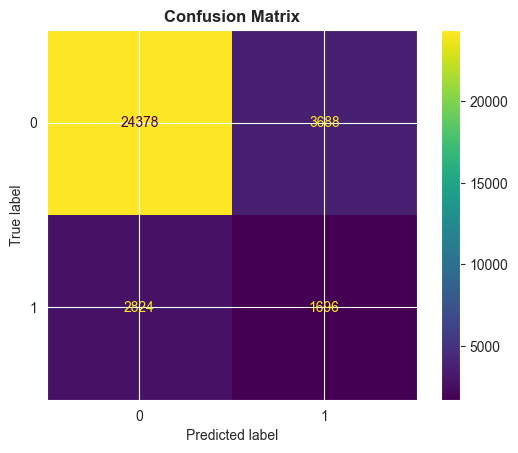

In [57]:
plot_confusion_matrix(ripper_model_chosen, test_labels, test_pred_ripper_under)

AUC-PR of the classifier: 0.3259
AUC-ROC of the classifier: 0.6252


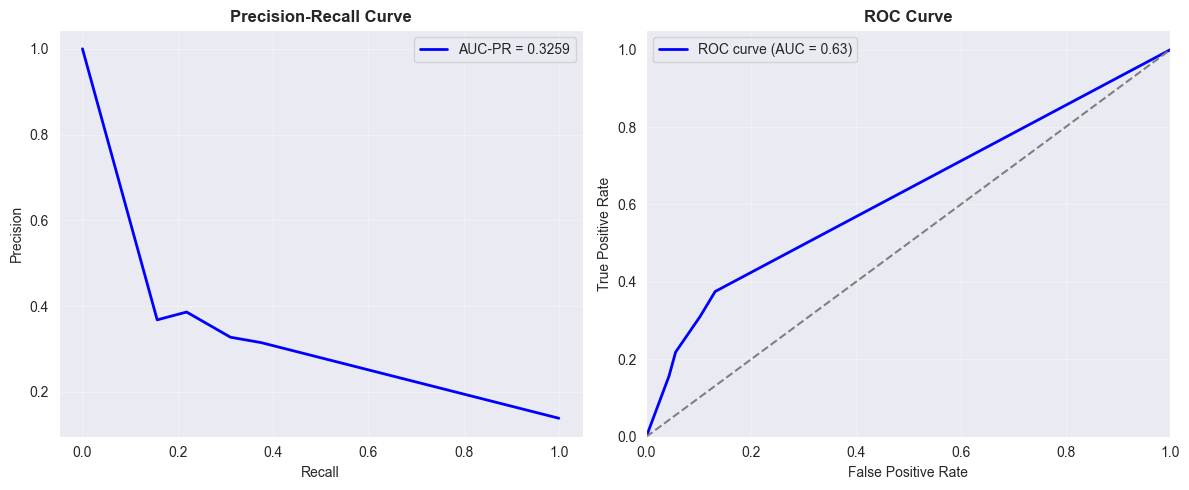

In [58]:
results_ripper_under = plot_PR_ROC_AUC(ripper_model_chosen, test_set, test_labels)

In [59]:
save_classification_res('ripper_under_sampling', best_params_knn_unders_from_gs, test_pred_ripper_under, results_ripper_under)

{'method_name': 'ripper_under_sampling', 'params': {'prune_size': 0.3, 'max_rules': 10, 'max_rule_conds': 5, 'k': 4}, 'predicted_labels': [False, False, True, True, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, True, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, 

## Model comparison

In [15]:
_, _, knn_smote_predicted_labels, knn_smote_probability_class_res = load_classification_res('knn_smote_sampling')

_, _, knn_under_predicted_labels, knn_under_probability_class_res = load_classification_res('knn_under_sampling')

_, _, linear_svm_under_predicted_labels, linear_svm_under_probability_class_res = load_classification_res('linear_svm_under_sampling')

_, _, rbf_svm_under_predicted_labels, rbf_svm_under_probability_class_res = load_classification_res('rbf_svm_under_sampling')

_, _, ripper_under_predicted_labels, ripper_under_probability_class_res = load_classification_res('ripper_under_sampling')

### ROC e PR curve comparison

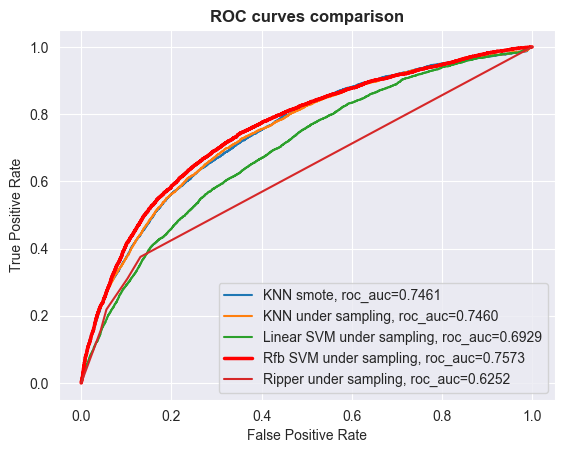

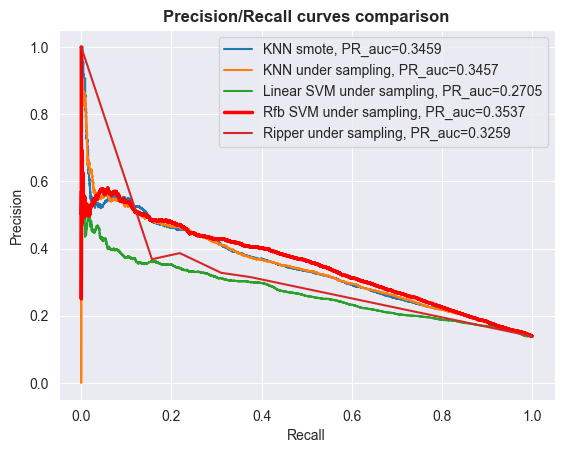

In [88]:
curves = [
    (knn_smote_probability_class_res, "KNN smote"),
    (knn_under_probability_class_res, "KNN under sampling"),
    (linear_svm_under_probability_class_res, "Linear SVM under sampling"),
    (rbf_svm_under_probability_class_res, "Rfb SVM under sampling"),
    (ripper_under_probability_class_res, "Ripper under sampling"),
]
compare_roc_curves(curves, title="ROC curves comparison")
compare_pr_curves(curves, title="Precision/Recall curves comparison")

### F1 macro model comparison

In [25]:
class ModelInfo:
    def __init__(self, name):
        self.name = name

In [27]:
test_predictions = [
    (knn_smote_predicted_labels, ModelInfo("KNN smote")),
    (knn_under_predicted_labels, ModelInfo("KNN under sampling")),
    (linear_svm_under_predicted_labels, ModelInfo("Linear SVM under sampling")),
    (rbf_svm_under_predicted_labels, ModelInfo("Rfb SVM under sampling")),
    (ripper_under_predicted_labels, ModelInfo("Ripper under sampling"))
]
model_infos = [model_info for _, model_info in test_predictions]
model_predictions = [predictions for predictions, _ in test_predictions]
compare_f1_score(model_infos, model_predictions, test_labels)

,Model,Macro F1-Score
3,Rfb SVM under sampling,0.640850
0,KNN smote,0.637014
1,KNN under sampling,0.634845
4,Ripper under sampling,0.612331
2,Linear SVM under sampling,0.591383
